# Basic Queries in SQL

### Connection with Database Server 


In [28]:
print("Hello, World!")

Hello, World!


## Connection Block

In [29]:
import oracledb 

username = "system"  
password = "password"  
host = "localhost" 
port = 1521  
service_name = "free" 
connection_string = f"{username}/{password}@{host}:{port}/{service_name}"
connection = oracledb.connect(connection_string)
print("Connection established.")

Connection established.


## Connection Testing by Fetching the actual data in database.

In [30]:
cursor = connection.cursor()
for row in cursor.execute("select * from employees"):
    print(row)

(7782, 'CLARK', 'MANAGER', 10)


fetch all the data

In [31]:
with connection.cursor() as cursor:
    cursor.execute("select * from users")
    row_one = cursor.fetchone()
    rows = cursor.fetchall()
    for r in rows:
        print(r)
    # for x in row_one:
    #     print(x)

(2, 'Bob')
(3, 'Charlie')
(4, 'David')
(5, 'Eve')
(6, 'Frank')


## Fetching all the data with the help of .cursor() and .execute() methods

In [32]:
sql = """select * from users where id in (:id1, :id2, :id3, :id4, :id5)"""

with connection.cursor() as cursor:
    cursor.execute(sql,
        id1=5, id2=7, id3=1, id4=3, id5=2)
    for row in cursor:
        print(row) 

(1, 'Alice')
(2, 'Bob')
(3, 'Charlie')
(5, 'Eve')


### Creating a new Table and Adding few values with execute() and executemany() methods

In [34]:
cursor = connection.cursor()
cursor.execute("create table mytab (id number, data varchar2(1000))")


In [35]:
cursor.execute("truncate table mytab")

sql = "insert into mytab (id, data) values (:idVal, :dataVal)"

# bind by position using a sequence (list or tuple)
cursor.execute(sql, [1, "String 1"])
cursor.execute(sql, (2, "String 2"))

# bind by name using a dictionary
cursor = connection.cursor()
cursor.execute(sql, {"idVal": 3, "dataVal": "String 3"})

# bind by name using keyword arguments
cursor.execute(sql, idVal=4, dataVal="String 4")

print("Done")

Done


In [36]:
cursor.execute("truncate table mytab")

rows = [ (1, "First" ),
	 (2, "Second" ),
	 (3, "Third" ),
	 (4, "Fourth" ),
	 (5, "Fifth" ),
	 (6, "Sixth" ),
	 (7, "Seventh" ) ]

# Using setinputsizes helps avoid memory reallocations.
# The parameters correspond to the insert columns.  
# The value None says use python-oracledb's default size for a NUMBER column.  
# The second value is the maximum input data (or column) width for the VARCHAR2 column
cursor.setinputsizes(None, 7)

cursor.executemany("insert into mytab(id, data) values (:1, :2)", rows)

# Now query the results back

for row in cursor.execute('select * from mytab'):
    print(row)

connection.rollback()

(1, 'First')
(2, 'Second')
(3, 'Third')
(4, 'Fourth')
(5, 'Fifth')
(6, 'Sixth')
(7, 'Seventh')


### Performance analysis for Execute() and executemany()

In [38]:
! pip install matplotlib

  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 3.2 MB/s  0:00:02m0:00:0100:01
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 6.0 MB/s  0:00:00 eta 0:00:01
Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl (64 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 8.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 10.7 MB/s  0:00:00 eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib]8 [matplotlib]


execute() loop      1 rows in 0.0008 seconds
executemany()       1 rows in 0.0003 seconds
execute() loop      5 rows in 0.0008 seconds
executemany()       5 rows in 0.0003 seconds
execute() loop     10 rows in 0.0014 seconds
executemany()      10 rows in 0.0002 seconds
execute() loop    100 rows in 0.0134 seconds
executemany()     100 rows in 0.0005 seconds
execute() loop   1000 rows in 0.1215 seconds
executemany()    1000 rows in 0.0037 seconds
Plot is:


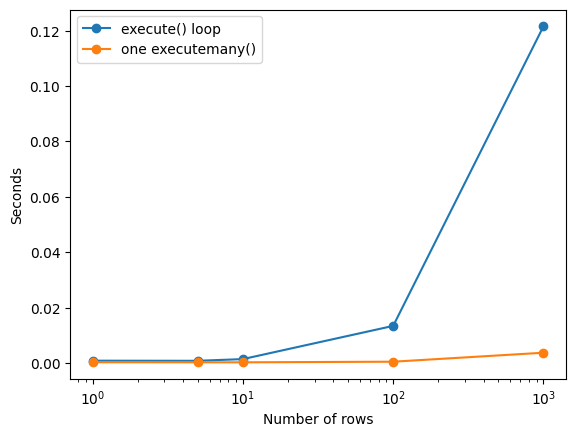

In [39]:
import matplotlib.pyplot as plt
import time

cursor = connection.cursor()
cursor.execute("truncate table mytab")

# Row counts to test inserting
numrows = (1, 5, 10, 100, 1000)

longstring = "x" * 1000

def create_data(n):
    d = []
    for i in range(n):
        d.append((i, longstring))
    return d

ex = []  # seconds for execute() loop
em = []  # seconds for executemany()

for n in numrows:
    
    rows = create_data(n)
    
    ############################################################
    #
    # Loop over each row
    #

    start=time.time()

    for r in rows:
        cursor.execute("insert into mytab(id, data) values (:1, :2)", r)          # <==== Loop over execute()
        
    elapsed = time.time() - start
    ex.append(elapsed)
    
    r, = cursor.execute("select count(*) from mytab").fetchone()
    print("execute() loop {:6d} rows in {:06.4f} seconds".format(r, elapsed))    
    connection.rollback()
    
    ############################################################# 
    #
    # Insert all rows in one call
    #

    start = time.time()

    cursor.executemany("insert into mytab(id, data) values (:1, :2)", rows)       # <==== One executemany()
    
    elapsed = time.time() - start
    em.append(elapsed)
    
    r, = cursor.execute("select count(*) from mytab").fetchone()
    print("executemany()  {:6d} rows in {:06.4f} seconds".format(r, elapsed))  
    connection.rollback()


print("Plot is:")
plt.xticks(numrows)
plt.plot(numrows, ex, label="execute() loop", marker="o")
plt.plot(numrows, em, label="one executemany()", marker="o")
plt.xscale("log")
plt.xlabel('Number of rows')
plt.ylabel('Seconds')
plt.legend(loc="upper left")
plt.show()